# Fase 6 — Analisi dei falsi positivi

Il cuore del progetto. Le Fasi 1-5 servivano ad arrivare qui.

**Domanda**: i 197 testi umani che il modello classifica come generati sono
un errore casuale, oppure condividono proprieta' misurabili?

**Ipotesi H2**: i falsi positivi si concentrano sui testi umani piu' formali,
piu' regolari e lessicalmente meno vari. Se e' vero, il classificatore non
separa "umano" da "macchina" ma "informale" da "formale", e il costo di
questo errore ricade sistematicamente su un tipo di scrittura invece che a
caso.

Se non emerge alcun pattern, e' comunque un risultato e va dichiarato.

## 0. Setup e ricostruzione dello stato

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE = RADICE / "results" / "figures"
TABELLE = RADICE / "results" / "tables"

SEED = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


def carica_modulo(nome_file: str, alias: str):
    percorso = RADICE / "src" / nome_file
    if not percorso.exists():
        candidati = sorted(p.name for p in (RADICE / "src").glob("*.py"))
        raise FileNotFoundError(f"{nome_file} non trovato. In src/: {candidati}")
    spec = importlib.util.spec_from_file_location(alias, percorso)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[alias] = modulo
    spec.loader.exec_module(modulo)
    return modulo


M = carica_modulo("models.py", "modelli")
E = carica_modulo("evaluation.py", "valutazione")

In [2]:
print(RADICE)

/Users/costanzastassi/Desktop/mgt-stylometry


Lo split viene rifatto con lo stesso seed della Fase 5: e' deterministico,
quindi le partizioni sono identiche. Il modello viene riaddestrato sul solo
train, senza il validation, esattamente come in Fase 5.

In [3]:
df = pd.read_parquet(RADICE / "data" / "processed" / "hc3_features.parquet")
COLS = M.colonne_feature(df)

train_completo, test = M.split_per_domanda(df, test_size=0.25)
train, valid = M.split_per_domanda(train_completo, test_size=0.20)

stilo = M.modello_stilometrico()
stilo.fit(train[COLS], train["label"])

test = test.copy()
test["pred"] = stilo.predict(test[COLS])
test["prob"] = stilo.predict_proba(test[COLS])[:, 1]

# Controllo: le metriche devono coincidere con quelle della Fase 5
print(E.valuta(test["label"], test["pred"], test["prob"], nome="stilometrico"))

{'modello': 'stilometrico', 'accuracy': 0.9191353082465973, 'precision': 0.9208199356913184, 'recall': 0.9171337069655725, 'f1': 0.918973124749298, 'fpr': np.float64(0.0788630904723779), 'n_falsi_positivi': 197, 'n_falsi_negativi': 207, 'auroc': 0.9706931277608155}


## 1. Isolare i falsi positivi

Quattro gruppi, non due: interessano soprattutto i falsi positivi (umano
predetto macchina) confrontati con i veri negativi (umano predetto umano).
Il confronto va fatto **dentro la classe umana**, altrimenti si misura la
differenza fra classi invece della struttura dell'errore.

In [4]:
umani = test[test["label"] == 0]
macchine = test[test["label"] == 1]

falsi_positivi = umani[umani["pred"] == 1]
veri_negativi = umani[umani["pred"] == 0]
falsi_negativi = macchine[macchine["pred"] == 0]

print(f"Testi umani nel test: {len(umani)}")
print(f"  falsi positivi (accusati a torto): {len(falsi_positivi)} "
      f"({len(falsi_positivi) / len(umani):.1%})")
print(f"  veri negativi:                     {len(veri_negativi)}")
print(f"Falsi negativi (generati non rilevati): {len(falsi_negativi)}")

Testi umani nel test: 2498
  falsi positivi (accusati a torto): 197 (7.9%)
  veri negativi:                     2301
Falsi negativi (generati non rilevati): 207


### I falsi positivi si distribuiscono uniformemente fra i domini?

Se un dominio e' colpito piu' degli altri, l'errore ha gia' una struttura.

In [5]:
per_dominio = pd.DataFrame({
    "n_umani": umani.groupby("domain").size(),
    "n_falsi_positivi": falsi_positivi.groupby("domain").size(),
}).fillna(0)
per_dominio["tasso_FP"] = per_dominio["n_falsi_positivi"] / per_dominio["n_umani"]
per_dominio = per_dominio.sort_values("tasso_FP", ascending=False)
per_dominio.to_csv(TABELLE / "falsi_positivi_per_dominio.csv")
per_dominio.round(3)

,n_umani,n_falsi_positivi,tasso_FP
domain,,,
wiki_csai,136,27,0.199
finance,521,49,0.094
reddit_eli5,1729,118,0.068
medicine,112,3,0.027


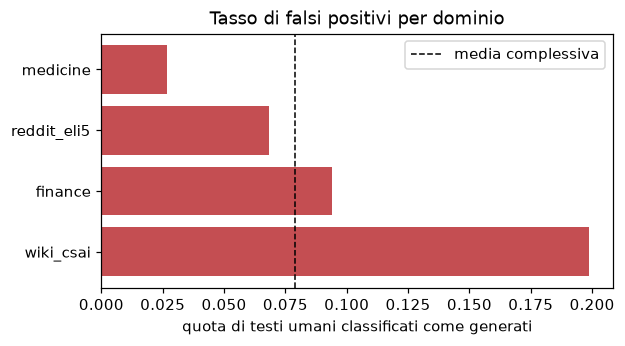

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(per_dominio.index, per_dominio["tasso_FP"], color="#C44E52")
ax.axvline(len(falsi_positivi) / len(umani), color="black",
           linestyle="--", linewidth=1, label="media complessiva")
ax.set_xlabel("quota di testi umani classificati come generati")
ax.set_title("Tasso di falsi positivi per dominio")
ax.legend()
fig.savefig(FIGURE / "08_fp_per_dominio.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Confronto statistico feature per feature

Mann-Whitney invece del test t: le feature non sono normali (molte hanno
distribuzioni asimmetriche e limite inferiore a zero) e il test e' non
parametrico.

**Correzione per test multipli obbligatoria**: con 30 feature e soglia 0.05
ci si attende circa 1.5 risultati "significativi" per puro caso. Si usa
Benjamini-Hochberg (FDR), meno conservativo di Bonferroni e adeguato a
un'analisi esplorativa.

Si riporta anche una misura di **dimensione dell'effetto**: con centinaia di
osservazioni un p-value piccolo puo' accompagnare una differenza
trascurabile. Il p-value dice se la differenza esiste, non se conta.

In [7]:
from scipy.stats import mannwhitneyu

try:
    from statsmodels.stats.multitest import multipletests
except ImportError:
    raise ImportError("Serve statsmodels: pip install statsmodels")


def delta_cliff(a, b) -> float:
    """Dimensione dell'effetto non parametrica, fra -1 e 1.

    Interpretazione convenzionale del valore assoluto:
    < 0.15 trascurabile, < 0.33 piccolo, < 0.47 medio, oltre grande.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    confronti = np.sign(a[:, None] - b[None, :])
    return float(confronti.mean())


righe = []
for col in COLS:
    a = falsi_positivi[col].values
    b = veri_negativi[col].values
    if len(a) < 3 or len(b) < 3:
        continue
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    righe.append({
        "feature": col,
        "media_FP": a.mean(),
        "media_VN": b.mean(),
        "media_macchina": macchine[col].mean(),
        "p_value": p,
        "delta_cliff": delta_cliff(a, b),
    })

confronto = pd.DataFrame(righe)
confronto["p_corretto"] = multipletests(confronto["p_value"], method="fdr_bh")[1]
confronto["significativo"] = confronto["p_corretto"] < 0.05
confronto["effetto_assoluto"] = confronto["delta_cliff"].abs()
confronto = confronto.sort_values("effetto_assoluto", ascending=False)
confronto.to_csv(TABELLE / "analisi_falsi_positivi.csv", index=False)

print(f"Feature significative dopo correzione FDR: "
      f"{confronto['significativo'].sum()} su {len(confronto)}")
confronto.head(15).round(4)

Feature significative dopo correzione FDR: 18 su 30


,feature,media_FP,media_VN,media_macchina,p_value,delta_cliff,p_corretto,significativo,effetto_assoluto
7,mattr,0.6151,0.6889,0.6113,0.0000,-0.5915,0.0000,True,0.5915
8,hapax_ratio,0.3633,0.4486,0.3281,0.0000,-0.4454,0.0000,True,0.4454
19,pos_adv,0.0378,0.0524,0.0342,0.0000,-0.3898,0.0000,True,0.3898
9,entropia,5.9118,6.1811,5.9934,0.0000,-0.3443,0.0000,True,0.3443
27,punt_per_100parole_parentesi,0.3503,0.8688,0.2159,0.0000,-0.3331,0.0000,True,0.3331
12,coordinate_per_frase,1.0836,0.7688,1.1833,0.0000,0.3118,0.0000,True,0.3118
0,lung_frase_media,23.1203,19.1209,23.2915,0.0000,0.2999,0.0000,True,0.2999
10,prof_albero_media,3.1508,2.7822,3.2399,0.0000,0.2802,0.0000,True,0.2802
22,pos_cconj,0.0376,0.0299,0.0411,0.0000,0.2685,0.0000,True,0.2685
15,ratio_pron_prima_persona,0.0056,0.0110,0.0033,0.0000,-0.2367,0.0000,True,0.2367


### La colonna decisiva

`media_macchina` e' la chiave di lettura: se sulle feature discriminanti i
falsi positivi hanno valori intermedi fra i veri negativi e i testi generati,
significa che sono testi umani **che assomigliano davvero alla macchina** su
quelle dimensioni. Non e' un capriccio del modello: e' una proprieta' dei
testi.

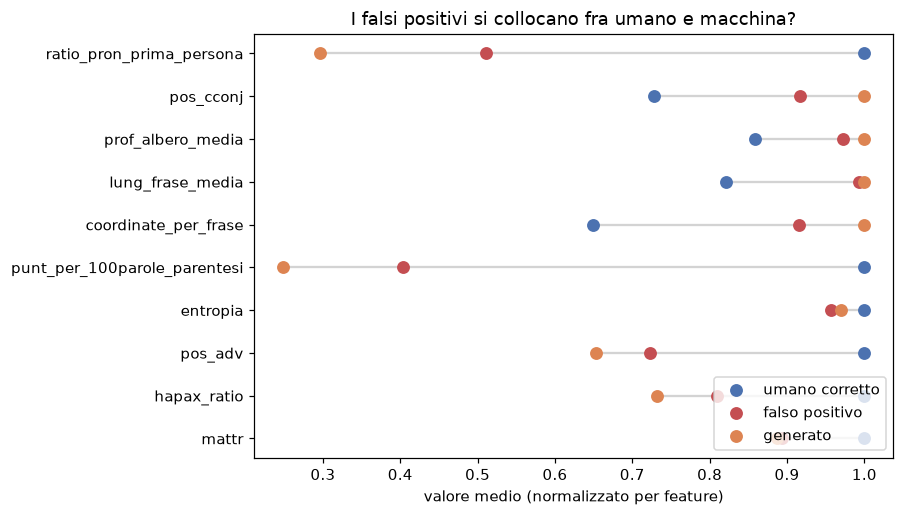

In [8]:
sig = confronto[confronto["significativo"]].nlargest(10, "effetto_assoluto")

fig, ax = plt.subplots(figsize=(7.5, 5))
y = np.arange(len(sig))

for i, (_, r) in enumerate(sig.iterrows()):
    valori = [r["media_VN"], r["media_FP"], r["media_macchina"]]
    scala = max(abs(v) for v in valori) or 1
    normalizzati = [v / scala for v in valori]
    ax.plot(normalizzati, [i, i, i], color="lightgray", zorder=1)
    ax.scatter(normalizzati[0], i, color="#4C72B0", s=55,
               label="umano corretto" if i == 0 else "", zorder=2)
    ax.scatter(normalizzati[1], i, color="#C44E52", s=55,
               label="falso positivo" if i == 0 else "", zorder=2)
    ax.scatter(normalizzati[2], i, color="#DD8452", s=55,
               label="generato" if i == 0 else "", zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(sig["feature"])
ax.set_xlabel("valore medio (normalizzato per feature)")
ax.set_title("I falsi positivi si collocano fra umano e macchina?")
ax.legend(loc="lower right")
fig.savefig(FIGURE / "09_fp_posizione.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Incrocio con i coefficienti del modello

Le feature su cui i falsi positivi differiscono sono le stesse su cui il
modello si appoggia di piu'? Se si', l'errore e' spiegato: quei testi
attivano i pesi che il modello ha imparato.

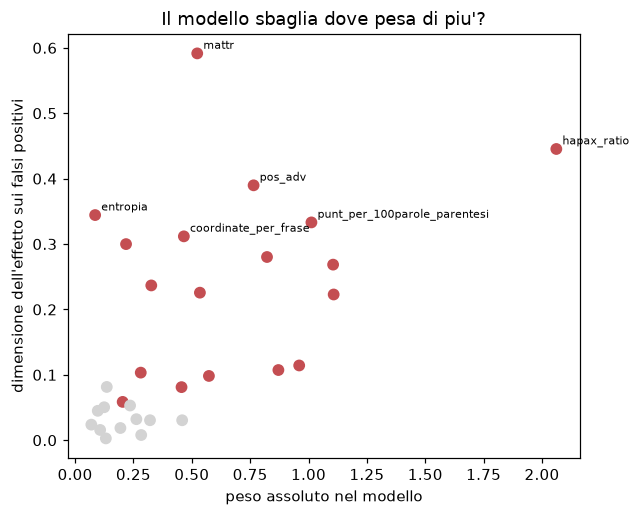

Correlazione fra peso nel modello ed effetto sui falsi positivi: 0.542


In [10]:
coef = pd.read_csv(TABELLE / "coefficienti_stilometrico.csv")
incrocio = confronto.merge(coef[["feature", "peso"]], on="feature")
incrocio["peso_assoluto"] = incrocio["peso"].abs()

fig, ax = plt.subplots(figsize=(6, 5))
colori = np.where(incrocio["significativo"], "#C44E52", "lightgray")
ax.scatter(incrocio["peso_assoluto"], incrocio["effetto_assoluto"],
           c=colori, s=45)

for _, r in incrocio.nlargest(6, "effetto_assoluto").iterrows():
    ax.annotate(r["feature"], (r["peso_assoluto"], r["effetto_assoluto"]),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points")

ax.set_xlabel("peso assoluto nel modello")
ax.set_ylabel("dimensione dell'effetto sui falsi positivi")
ax.set_title("Il modello sbaglia dove pesa di piu'?")
fig.savefig(FIGURE / "10_peso_vs_effetto.png", dpi=150, bbox_inches="tight")
plt.show()

correlazione = incrocio[["peso_assoluto", "effetto_assoluto"]].corr().iloc[0, 1]
print(f"Correlazione fra peso nel modello ed effetto sui falsi positivi: "
      f"{correlazione:.3f}")

## 4. Confidenza degli errori

Il modello sbaglia con incertezza o con sicurezza? Un classificatore che
sbaglia a probabilita' 0.51 e' meno preoccupante di uno che sbaglia a 0.95,
soprattutto se qualcuno dovesse usarlo per prendere decisioni.

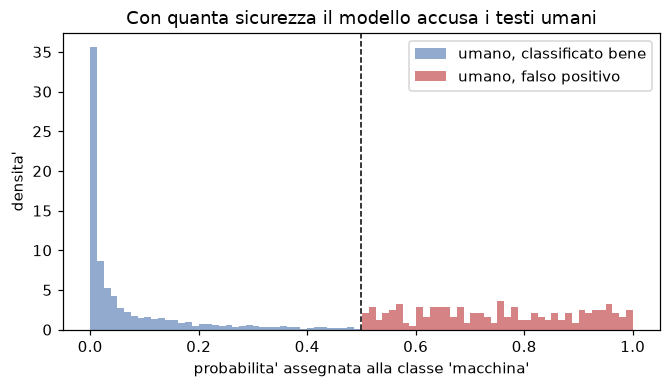

Falsi positivi con probabilita' > 0.7: 115 (58.4% degli errori)
Falsi positivi con probabilita' > 0.8: 76 (38.6% degli errori)
Falsi positivi con probabilita' > 0.9: 46 (23.4% degli errori)
Falsi positivi con probabilita' > 0.95: 23 (11.7% degli errori)


In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(veri_negativi["prob"], bins=40, alpha=0.6,
        label="umano, classificato bene", color="#4C72B0", density=True)
ax.hist(falsi_positivi["prob"], bins=40, alpha=0.7,
        label="umano, falso positivo", color="#C44E52", density=True)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("probabilita' assegnata alla classe 'macchina'")
ax.set_ylabel("densita'")
ax.set_title("Con quanta sicurezza il modello accusa i testi umani")
ax.legend()
fig.savefig(FIGURE / "11_confidenza_errori.png", dpi=150, bbox_inches="tight")
plt.show()

for soglia in [0.7, 0.8, 0.9, 0.95]:
    n = (falsi_positivi["prob"] > soglia).sum()
    print(f"Falsi positivi con probabilita' > {soglia}: {n} "
          f"({n / len(falsi_positivi):.1%} degli errori)")

### Alzare la soglia risolve?

Se il costo dei falsi positivi e' asimmetrico, si potrebbe alzare la soglia
di decisione. Questa tabella mostra il prezzo: ogni riduzione di falsi
positivi si paga in testi generati non rilevati.

In [12]:
righe = []
for soglia in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    pred = (test["prob"] > soglia).astype(int)
    r = E.valuta(test["label"], pred, test["prob"], nome=f"soglia {soglia}")
    r["soglia"] = soglia
    righe.append(r)

soglie = pd.DataFrame(righe)[
    ["soglia", "accuracy", "recall", "fpr", "n_falsi_positivi", "n_falsi_negativi"]
]
soglie.to_csv(TABELLE / "soglie_decisione.csv", index=False)
soglie.round(4)

,soglia,accuracy,recall,fpr,n_falsi_positivi,n_falsi_negativi
0,0.50,0.9191,0.9171,0.0789,197,207
1,0.60,0.9117,0.8875,0.0641,160,281
2,0.70,0.9041,0.8543,0.0460,115,364
3,0.80,0.8843,0.7990,0.0304,76,502
4,0.90,0.8295,0.6773,0.0184,46,806
5,0.95,0.7660,0.5412,0.0092,23,1146


## 5. Cinque casi commentati

L'analisi qualitativa che il documento del docente chiede accanto a quella
quantitativa. Leggere i testi, non solo stamparli.

In [13]:
def mostra(riga, larghezza=95):
    print("=" * larghezza)
    print(f"dominio: {riga['domain']}   "
          f"prob(macchina) = {riga['prob']:.3f}   "
          f"parole = {riga['n_parole']}")
    print(f"hapax={riga['hapax_ratio']:.3f}  "
          f"lung_frase_std={riga['lung_frase_std']:.1f}  "
          f"prof_albero={riga['prof_albero_media']:.2f}")
    print("-" * larghezza)
    t = riga["text"]
    for i in range(0, len(t), larghezza):
        print(t[i:i + larghezza])
    print()


print("### I CINQUE FALSI POSITIVI PIU' SICURI ###\n")
for _, r in falsi_positivi.nlargest(5, "prob").iterrows():
    mostra(r)

### I CINQUE FALSI POSITIVI PIU' SICURI ###

dominio: reddit_eli5   prob(macchina) = 1.000   parole = 143
hapax=0.422  lung_frase_std=0.0  prof_albero=6.30
-----------------------------------------------------------------------------------------------
There are a lot of factors that go into a successful self - alley oop that make it incredibly d
ifficult to pull off: - you need to be at an angle where you can make the catch after it bounce
s off the backboard - you need to throw it with just enough power to place it so you can catch 
and dunk the ball - you need to be able to get around your defender to go catch your pass - you
 need to pray that none of the defenders decide to grab the rebound after it hits the backboard
 - you need to hope it doesn't hit the rim and shoot off god - knows - where Basically, you don
't see it very often because it's tough as hell to pull off, and if you miss it, you look like 
a moron.

dominio: wiki_csai   prob(macchina) = 1.000   parole = 121
hapax=0

In [15]:
# Confronto: testi umani che il modello riconosce con piu' sicurezza.
# Serve a vedere il contrasto.
print("### I TRE UMANI PIU' RICONOSCIBILI ###\n")
for _, r in veri_negativi.nsmallest(3, "prob").iterrows():
    mostra(r)

### I TRE UMANI PIU' RICONOSCIBILI ###

dominio: reddit_eli5   prob(macchina) = 0.000   parole = 219
hapax=0.620  lung_frase_std=34.1  prof_albero=4.47
-----------------------------------------------------------------------------------------------
Among other things, he... * generally censored and suppressed dissent in Libya, including killi
ng members of rival political groups; * sent assassins to kill various people in other countrie
s who criticized him; * severely oppressed the Berber ethnic minority, including banning their 
language from schools; * attempted to ban English foreign - language education and promote Russ
ian in order to cozy up to the Soviet Union; * switched from oppressive Sovietism to oppressive
 Islamism in the ' 90s, enacting mutilation as punishment and forbidding women from entering pu
blic life; * tried (and failed) to invade and conquer Chad; * ordered a (failed) attack on the 
civilian ship * RMS Queen Elizabeth 2 *; * expelled Palestinian refugees in 1995

In [ ]:
# Commenti ai cinque casi. Da compilare a mano dopo la lettura.
commenti = """
Caso 1:
Caso 2:
Caso 3:
Caso 4:
Caso 5:

Tratti ricorrenti:
"""
print(commenti)

## 6. Falsi negativi

Speculare e piu' breve: quali testi generati sfuggono? Se sono i piu' corti
o i piu' informali, la conclusione e' simmetrica.

In [14]:
righe = []
veri_positivi = macchine[macchine["pred"] == 1]
for col in COLS:
    a = falsi_negativi[col].values
    b = veri_positivi[col].values
    if len(a) < 3 or len(b) < 3:
        continue
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    righe.append({"feature": col, "media_FN": a.mean(), "media_VP": b.mean(),
                  "p_value": p, "delta_cliff": delta_cliff(a, b)})

fn = pd.DataFrame(righe)
fn["p_corretto"] = multipletests(fn["p_value"], method="fdr_bh")[1]
fn["effetto_assoluto"] = fn["delta_cliff"].abs()
fn = fn.sort_values("effetto_assoluto", ascending=False)
fn.to_csv(TABELLE / "analisi_falsi_negativi.csv", index=False)
fn.head(10).round(4)

,feature,media_FN,media_VP,p_value,delta_cliff,p_corretto,effetto_assoluto
8,hapax_ratio,0.4062,0.3211,0.0,0.4454,0.0,0.4454
10,prof_albero_media,2.9096,3.2698,0.0,-0.4013,0.0,0.4013
0,lung_frase_media,21.1460,23.4854,0.0,-0.3498,0.0,0.3498
12,coordinate_per_frase,0.9109,1.2079,0.0,-0.3492,0.0,0.3492
22,pos_cconj,0.0325,0.0419,0.0,-0.3243,0.0,0.3243
7,mattr,0.6454,0.6083,0.0,0.2912,0.0,0.2912
19,pos_adv,0.0456,0.0331,0.0,0.2842,0.0,0.2842
14,ratio_hedging,0.0101,0.0162,0.0,-0.2816,0.0,0.2816
16,pos_noun,0.1953,0.2153,0.0,-0.2307,0.0,0.2307
13,ratio_connettivi,0.0014,0.0029,0.0,-0.2248,0.0,0.2248


## 7. Conclusioni

Da compilare **dopo** aver guardato i risultati, rispondendo a queste
domande in modo esplicito.

In [15]:
conclusioni = """
1. H2 e' confermata, parzialmente confermata o smentita?

2. Su quali feature i falsi positivi si discostano di piu' dai veri negativi,
   e in che direzione?

3. I falsi positivi hanno valori intermedi fra umano e macchina, oppure sono
   fuori scala in una direzione?

4. Il tasso di errore varia fra domini? Se si', quale ne paga il prezzo?

5. Che tipo di scrittura umana viene penalizzata? Con quali conseguenze
   pratiche se lo strumento fosse usato in ambito didattico?

6. Alzare la soglia di decisione risolve il problema, e a quale costo?
"""
print(conclusioni)


1. H2 e' confermata, parzialmente confermata o smentita?

2. Su quali feature i falsi positivi si discostano di piu' dai veri negativi,
   e in che direzione?

3. I falsi positivi hanno valori intermedi fra umano e macchina, oppure sono
   fuori scala in una direzione?

4. Il tasso di errore varia fra domini? Se si', quale ne paga il prezzo?

5. Che tipo di scrittura umana viene penalizzata? Con quali conseguenze
   pratiche se lo strumento fosse usato in ambito didattico?

6. Alzare la soglia di decisione risolve il problema, e a quale costo?



### Limite da dichiarare

Questa analisi descrive **come** il modello sbaglia, non stabilisce un
rapporto causale. Le feature su cui i falsi positivi si distinguono sono
correlate all'errore; affermare che lo causano richiederebbe un intervento
controllato — ad esempio riscrivere testi umani modificando una sola
proprieta' alla volta e osservare se la classificazione cambia.